In [475]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
from matplotlib.ticker import FuncFormatter
import plotly.express as px

In [476]:
enrolment_data=pd.read_csv("/content/final_enrol_data")
demographic_data=pd.read_csv("/content/Final_demo_data.csv")
biometric_data=pd.read_csv("/content/final_bio_data.csv")

In [477]:
enrol_data=enrolment_data.copy()
demo_data=demographic_data.copy()
bio_data=biometric_data.copy()

### Checking Duplicates

In [478]:
enrol_data.duplicated().sum()

np.int64(22957)

In [479]:
demo_data.duplicated().sum()

np.int64(473601)

In [480]:
bio_data.duplicated().sum()

np.int64(94896)

In [481]:
enrol_data.drop_duplicates(inplace=True)
demo_data.drop_duplicates(inplace=True)
bio_data.drop_duplicates(inplace=True)

### Checking Null Values

In [482]:
enrol_data.isnull().sum()

,0
date,0
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0


In [483]:
demo_data.isnull().sum()

,0
date,0
state,0
district,0
pincode,0
demo_age_5_17,0
demo_age_17_,0


In [484]:
bio_data.isnull().sum()

,0
date,0
state,0
district,0
pincode,0
bio_age_5_17,0
bio_age_17_,0


### Regex for state and district columns

In [485]:
def normalize_text(series: pd.Series) -> pd.Series:
    return (
        series
        .astype(str)
        .str.lower()
        .str.strip()

        # replace mojibake dash artifacts with space
        .str.replace(r'â[\x80-\x9f]+', ' ', regex=True)

        # replace all hyphen/dash variants with space (FIXED)
        .str.replace(r'[-‐‒–—−]', ' ', regex=True)
        .str.replace(r'[‐-‒–—−]', ' ', regex=True)

        # replace punctuation/symbols with space
        .str.replace(r'[?&/.,*\'"]', ' ', regex=True)

        # remove bracketed text
        .str.replace(r'\(.*?\)', '', regex=True)

        # collapse multiple spaces
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
def normalize_columns(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = normalize_text(df[col])
    return df
def apply_value_map(
    df: pd.DataFrame,
    column: str,
    mapping: dict,
    dropna: bool = False
) -> pd.DataFrame:
    df = df.copy()
    df[column] = df[column].replace(mapping)
    if dropna:
        df = df.dropna(subset=[column])
    return df

In [486]:
enrol_data=normalize_columns(enrol_data,['state','district'])
demo_data=normalize_columns(demo_data,['state','district'])
bio_data=normalize_columns(bio_data,['state','district'])

### state column

In [487]:
enrol_data['state'].nunique()

48

In [488]:
demo_data['state'].nunique()

57

In [489]:
bio_data['state'].nunique()

49

In [490]:
demo_data['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'odisha', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'dadra and nagar haveli and daman and diu',
       'dadra and nagar haveli', 'orissa', 'pondicherry',
       'andaman nicobar islands', 'andaman and nicobar islands',
       'daman diu', 'jammu kashmir', 'lakshadweep', 'dadra nagar haveli',
       'westbengal', 'west bangal', 'chhatisgarh', 'west bengli',
       'darbhanga', 'puttenahalli', 'uttaranchal', 'balanagar', 'jaipur',
       'madanapalle', '100000', 'nagpur', 'raja annamalai puram'],
      dtype=object)

In [491]:
state_fix_map = {
    # Jammu & Kashmir
    'jammu kashmir': 'jammu and kashmir',

    # Odisha
    'orissa': 'odisha',

    # Dadra & Daman merged UT
    'the dadra and nagar haveli and daman and diu': 'dadra and nagar haveli and daman and diu',
    'dadra nagar haveli': 'dadra and nagar haveli and daman and diu',
    'dadra and nagar haveli': 'dadra and nagar haveli and daman and diu',
    'daman and diu': 'dadra and nagar haveli and daman and diu',
    'daman diu': 'dadra and nagar haveli and daman and diu',

    # Andaman
    'andaman nicobar islands': 'andaman and nicobar islands',

    # West Bengal
    'west bangal': 'west bengal',
    'westbengal': 'west bengal',
    'west bengli': 'west bengal',

    # Puducherry
    'pondicherry': 'puducherry',

    # Chhattisgarh
    'chhatisgarh': 'chhattisgarh',

    # Uttarakhand
    'uttaranchal': 'uttarakhand',

    # Tamil Nadu
    'tamilnadu': 'tamil nadu',

    # Garbage
    '100000': None
}


In [492]:
enrol_data  = apply_value_map(enrol_data,  'state', state_fix_map, dropna=True)

In [493]:
enrol_data['state'].nunique()

36

In [494]:
bio_data  = apply_value_map(bio_data,  'state', state_fix_map, dropna=True)

In [495]:
bio_data['state'].unique()

array(['haryana', 'bihar', 'jammu and kashmir', 'tamil nadu',
       'maharashtra', 'gujarat', 'odisha', 'west bengal', 'kerala',
       'rajasthan', 'punjab', 'himachal pradesh', 'uttar pradesh',
       'assam', 'uttarakhand', 'madhya pradesh', 'karnataka',
       'andhra pradesh', 'telangana', 'goa', 'nagaland', 'jharkhand',
       'delhi', 'chhattisgarh', 'meghalaya', 'chandigarh', 'puducherry',
       'manipur', 'sikkim', 'tripura', 'mizoram', 'arunachal pradesh',
       'ladakh', 'dadra and nagar haveli and daman and diu',
       'andaman and nicobar islands', 'lakshadweep'], dtype=object)

In [496]:
demo_data = apply_value_map(demo_data, 'state', state_fix_map, dropna=True)


In [497]:
demo_data['state'].nunique()

43

In [498]:
demo_data['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'odisha', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur',
       'dadra and nagar haveli and daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'darbhanga', 'puttenahalli', 'balanagar', 'jaipur', 'madanapalle',
       'nagpur', 'raja annamalai puram'], dtype=object)

In [499]:
demo_data[demo_data['state']=='nagpur']

,date,state,district,pincode,demo_age_5_17,demo_age_17_
1533255,22-12-2025,nagpur,near uday nagar nit garden,440024,0,1


In [500]:
# 3.Identify Invalid State Values , Cities, districts, pincodes in state column (Jaipur, Nagpur, Darbhanga, 100000)




valid_states = [
       'haryana', 'bihar', 'jammu and kashmir', 'tamil nadu',
       'maharashtra', 'gujarat', 'odisha', 'west bengal', 'kerala',
       'rajasthan', 'punjab', 'himachal pradesh', 'uttar pradesh',
       'assam', 'uttarakhand', 'madhya pradesh', 'karnataka',
       'andhra pradesh', 'telangana', 'goa', 'nagaland', 'jharkhand',
       'delhi', 'chhattisgarh', 'meghalaya', 'chandigarh', 'puducherry',
       'manipur', 'sikkim', 'tripura', 'mizoram', 'arunachal pradesh',
       'ladakh', 'dadra and nagar haveli and daman and diu',
       'andaman and nicobar islands', 'lakshadweep'

]

In [501]:
# Rows with invalid state values may be  dropped as they are very less in number
# Keep only valid states / UTs
demo_data = demo_data[demo_data['state'].isin(valid_states)]

In [502]:
demo_data['state'].nunique()

36

### district column

In [503]:
enrol_data['district'].nunique()

932

In [504]:
demo_data['district'].nunique()

920

In [505]:
bio_data['district'].nunique()

918

In [506]:
district_fix_map = {
    'allahabad':'prayagraj',
    'ahmadabad': 'ahmedabad',
    'ahmadnagar': 'ahilyanagar',
    'ahmed nagar': 'ahilyanagar',
    'ahmednagar':'ahilyanagar',
    'ananthapuramu': 'anantapuramu',
    'tiruvallur': 'thiruvallur',
    'anantapur': 'anantapuramu',
    'ananthapur':'anantapuramu',
    'ashok nagar': 'ashoknagar',
    'anugul': 'angul',
    'anugal': 'angul',
    'banas kantha': 'banaskantha',
    'bid':'beed',
    'bellary':'ballari',
    'belgaum':'belagavi',
    'bulandshahar': 'bulandshahr',
    'barddhaman': 'bardhaman',
    'baleshwar': 'baleswar',
    'barabanki': 'bara banki',
    'baudh': 'boudh',
    'bandipore': 'bandipora',
    'bandipur': 'bandipora',
    'buldana': 'buldhana',
    'baghpat': 'bagpat',
    'bangalore': 'bengaluru',
    'bangalore rural': 'bengaluru rural',
    'chamrajanagar': 'chamarajanagar',
    'chamrajnagar': 'chamarajanagar',
    'chickmagalur': 'chikkamagaluru',
    'chikmagalur': 'chikkamagaluru',
    'chhatrapati sambhajinagar': 'chatrapati sambhaji nagar',
    'coochbehar': 'cooch behar',
    'koch bihar': 'cooch behar',
    'chittaurgarh': 'chittorgarh',
    'cuddapah':'y s r kadapa',
    'dakshin bastar dantewada': 'dantewada',
    'davangere': 'davanagere',
    'dadra nagar haveli': 'dadra and nagar haveli',
    'dinajpur dakshin': 'dakshin dinajpur',
    'dhaulpur': 'dholpur',
    'darjiling': 'darjeeling',
    'east singhbum': 'east singhbhum',
    'east midnapur': 'purba medinipur',
    'east': 'east sikkim',
    'faizabad':'ayodhya',
    'ferozepur': 'firozpur',
    'gaurella pendra marwahi': 'gaurela penda marwahi',
    'gaurela pendra marwahi': 'gaurela penda marwahi',
    'gurgaon': 'gurugram',
    'gondiya': 'gondia',
    'garhwal': 'pauri garhwal',
    'hasan': 'hassan',
    'hugli': 'hooghly',
    'hooghiy': 'hooghly',
    'haora': 'howrah',
    'hardwar': 'haridwar',
    'hawrah': 'howrah',
    'hazaribag': 'hazaribagh',
    'hoshangabad':'narmadapuram',
    'jagatsinghapur': 'jagatsinghpur',
    'jajapur': 'jajpur',
    'jhunjhunun': 'jhunjhunu',
    'jalor': 'jalore',
    'jangoan': 'jangaon',
    'kasargod': 'kasaragod',
    'ranga reddy': 'rangareddy',
    'kv rangareddy':'rangareddy',
    'k.v. rangareddy': 'rangareddy',
    'k.v.rangareddy': 'rangareddy',
    'rangareddi': 'rangareddy',
    'karim nagar': 'karimnagar',
    'kushi nagar': 'kushinagar',
    'kancheepuram': 'kanchipuram',
    'khorda': 'khordha',
    'kodarma': 'koderma',
    'east nimar':'khandwa',
    'west nimar':'khargone',
    'kawardha':'kabeerdham',
    'lahul spiti': 'lahaul and spiti',
    'lahul and spiti': 'lahaul and spiti',
    'mahbubnagar': 'mahabubnagar',
    'mahbub nagar': 'mahabubnagar',
    'mahabub nagar': 'mahabubnagar',
    'medinipur west': 'paschim medinipur',
    'mohalla manpur ambagarh chowki': 'mohla manpur ambagarh chowki',
    'mohla manpur ambagarh chouki': 'mohla manpur ambagarh chowki',
    'mammit': 'mamit',
    'malda': 'maldah',
    'monghyr':'munger',
    'mysore': 'mysuru',
    'mewat':'nuh',
    'narsimhapur': 'narmadapuram',
    'nicobars': 'nicobar',
    'nabarangapur': 'nabarangpur',
    'nellore': 'sri potti sriramulu nellore',
    'north': 'north sikkim',
    'osmanabad':'dharashiv',
    'panch mahals':'panchmahals',
    'purbi champaran':'east champaran',
    'purba champaran':'east champaran',
    'pashchim champaran':'west champaran',
    'palamau': 'palamu',
    'purnia': 'purnea',
    'puruliya': 'purulia',
    'pondicherry': 'puducherry',
    'rajauri': 'rajouri',
    'raebareli': 'rae bareli',
    'ramanagara': 'ramanagar',
    'sheikpura': 'sheikhpura',
    'sahebganj': 'sahibganj',
    'shimoga': 'shivamogga',
    'tumkur': 'tumakuru',
    'sundergarh': 'sundargarh',
    'viluppuram': 'villupuram',
    'west midnapore': 'paschim medinipur',
    '24 paraganas north': 'north 24 parganas',
    'north twenty four parganas': 'north 24 parganas',
    'south twenty four parganas': 'south 24 parganas',
    'south 24 pargana': 'south 24 parganas',
    'sant ravidas nagar': 'sant ravidas nagar bhadohi',
    '24 paraganas south': 'south 24 parganas',
    'tiruvarur': 'thiruvarur',
    'visakhapatanam': 'visakhapatnam',
    'burdwan': 'bardhaman',
    'tuticorin': 'thoothukkudi',
    's.a.s nagar': 'sas nagar',
    'shrawasti': 'shravasti',
    'siddharth nagar': 'siddharthnagar',
    'yamuna nagar': 'yamunanagar',
    'yadadri.': 'yadadri bhuvanagiri',
    'sabar kantha': 'sabarkantha',
    'surendra nagar': 'surendranagar',
    'y s r': 'y s r kadapa',
    'south': 'south sikkim',
    "bengaluru": "bengaluru urban",
    "bengaluru south": "bengaluru urban",
    "mewat": "nuh",
    "spsr nellore": "nellore",
    "sri potti sriramulu nellore": "nellore",
    "sibsagar": "sivasagar",
    "samstipur": "samastipur",
    "shupiyan": "shopian",
    "dohad": "dahod",
    "dinajpur uttar": "north dinajpur",
    "north cachar hills": "dima hasao",
    "gulbarga": "kalaburagi",
    "baleswar": "balasore",
    "sri potti sriramulu nellore": "nellore",
    "jyotiba phule nagar": "amroha",
    "dr b r ambedkar konaseema": "konaseema",
    "k v rangareddy": "rangareddy",
    "y s r kadapa": "kadapa",
    "dist : thane": "thane",
    "tamulpur district": "tamulpur",
    "the dangs": "dang",
    "the nilgiris": "nilgiris",
    "balianta": "khordha",
    "bally jagachha": "howrah",
    "domjur": "howrah",
    "south dumdum": "north 24 parganas",
    "naihati anandabazar": "north 24 parganas",
    'bicholim':'north goa',
    'mohali':'s a s nagar',
    'kanyakumari': 'kanniyakumari',
    'west':'west sikkim',
    'manendragarhchirmiribharatpur':'manendragarh chirmiri bharatpur',

}

In [507]:
enrol_data=apply_value_map(enrol_data,'district',district_fix_map,dropna=True)

In [508]:
enrol_data['district'].nunique()

796

In [509]:
demo_data=apply_value_map(demo_data,'district',district_fix_map,dropna=True)

In [510]:
demo_data['district'].nunique()

802

In [511]:
bio_data=apply_value_map(bio_data,'district',district_fix_map,dropna=True)

In [512]:
bio_data['district'].nunique()

802

The number of unique districts differs slightly across datasets because enrolment data covers only districts with active enrolments, whereas demographic and biometric datasets have broader geographic coverage. This difference is expected and does not impact the analysis.

In [513]:
def apply_special_fixes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df.loc[(df['state'] == 'maharashtra') & (df['district'] == 'raigarh'), 'district'] = 'raigad'
    df.loc[(df['district'] == 'rupnagar') & (df['state'] == 'chandigarh'), 'state'] = 'punjab'
    df.loc[(df['district'] == 'bijapur') & (df['state'] == 'karnataka'), 'district'] = 'vijayapura'
    df.loc[(df['district'] == 'kamrup') & (df['state'] == 'meghalaya'), 'state'] = 'assam'

    return df


In [514]:
enrol_data = apply_special_fixes(enrol_data)
demo_data = apply_special_fixes(demo_data)
bio_data = apply_special_fixes(bio_data)

In [515]:
from typing import List

def fix_state_by_district(
    dfs: List[pd.DataFrame],
    districts: list[str],
    from_state: str,
    to_state: str
) -> List[pd.DataFrame]:

    fixed_dfs = []

    for df in dfs:
        df = df.copy()
        mask = df['district'].isin(districts) & (df['state'] == from_state)
        df.loc[mask, 'state'] = to_state
        fixed_dfs.append(df)

    return fixed_dfs

In [516]:
enrol_data,demo_data,bio_data = fix_state_by_district(
    [enrol_data,demo_data,bio_data],
    districts=[
        'adilabad','hyderabad','karimnagar','khammam','medak',
        'nalgonda','nizamabad','rangareddy','warangal','mahabubnagar'
    ],
    from_state='andhra pradesh',
    to_state='telangana'
)

In [517]:
enrol_data,demo_data,bio_data = fix_state_by_district(
    [enrol_data,demo_data,bio_data],
    districts=[
        'kargil', 'leh'
    ],
    from_state='jammu kashmir',
    to_state='ladakh'
)

In [518]:
def aggregate(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df
        .groupby(['date', 'state', 'district', 'pincode'], as_index=False)
        .sum()
    )

In [519]:
enrol_data=aggregate(enrol_data)
demo_data=aggregate(demo_data)
bio_data=aggregate(bio_data)


In [520]:
enrol_data.duplicated().sum()
demo_data.duplicated().sum()
bio_data.duplicated().sum()

np.int64(0)

In [521]:
bio_data['date'].isnull().sum()

np.int64(0)

### Data Merging

In [522]:
enrol_data=enrol_data.rename(columns={
    'age_0_5':'enrol_age_0_5',
    'age_5_17':'enrol_age_5_17',
    'age_18_greater':'enrol_age_18_plus'
})
demo_data=demo_data.rename(columns={
    'demo_age_17_':'demo_age_17_plus'
})
bio_data=bio_data.rename(columns={
    'bio_age_17_':'bio_age_17_plus'
})

In [523]:
def merge_dataframes(
    dfs: list[pd.DataFrame],
    keys: list[str],
    fill_zero_cols: list[str]
) -> pd.DataFrame:
  # 1. Merge all DataFrames using outer join
    merged_df = reduce(
        lambda left, right: left.merge(right, on=keys, how='outer'),
        dfs
    )

    # 2. Fill NaN only in explicitly provided columns
    cols_to_fill = [c for c in fill_zero_cols if c in merged_df.columns]
    merged_df[cols_to_fill] = merged_df[cols_to_fill].fillna(0)

    # 3. Downcast integer columns (safe & memory efficient)
    for col in merged_df.select_dtypes(include=['int64', 'int32','float64']).columns:
        merged_df[col] = pd.to_numeric(merged_df[col], downcast='integer')

    return merged_df

In [524]:
KEYS = ['date', 'state', 'district', 'pincode']

COUNT_COLS = [
    'enrol_age_0_5',
    'enrol_age_5_17',
    'enrol_age_18_plus',
    'demo_age_5_17',
    'demo_age_17_plus',
    'bio_age_5_17',
    'bio_age_17_plus',
]



In [525]:
final_df = merge_dataframes(
    dfs=[enrol_data, demo_data, bio_data],
    keys=KEYS,
    fill_zero_cols=COUNT_COLS
)


In [526]:
final_df['date'] = pd.to_datetime(final_df['date'], format='%d-%m-%Y', errors='coerce')

In [527]:
# making state and district for data optimization
final_df['state'] =final_df['state'].astype('category')
final_df['district'] =final_df['district'].astype('category')

In [528]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2094336 entries, 0 to 2094335
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   date               datetime64[ns]
 1   state              category      
 2   district           category      
 3   pincode            int32         
 4   enrol_age_0_5      int16         
 5   enrol_age_5_17     int16         
 6   enrol_age_18_plus  int16         
 7   demo_age_5_17      int16         
 8   demo_age_17_plus   int16         
 9   bio_age_5_17       int16         
 10  bio_age_17_plus    int16         
dtypes: category(2), datetime64[ns](1), int16(7), int32(1)
memory usage: 58.0 MB


In [529]:
final_df.to_csv("Final_clean_data.csv",index=False)

In [530]:
df=pd.read_csv("/content/Final_clean_data.csv")

In [531]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2094336 entries, 0 to 2094335
Data columns (total 11 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   date               object
 1   state              object
 2   district           object
 3   pincode            int64 
 4   enrol_age_0_5      int64 
 5   enrol_age_5_17     int64 
 6   enrol_age_18_plus  int64 
 7   demo_age_5_17      int64 
 8   demo_age_17_plus   int64 
 9   bio_age_5_17       int64 
 10  bio_age_17_plus    int64 
dtypes: int64(8), object(3)
memory usage: 175.8+ MB


In [533]:
df

,date,state,district,pincode,enrol_age_0_5,enrol_age_5_17,enrol_age_18_plus,demo_age_5_17,demo_age_17_plus,bio_age_5_17,bio_age_17_plus
0,2025-03-01,andaman and nicobar islands,andamans,744101,0,0,0,0,0,16,193
1,2025-03-01,andaman and nicobar islands,nicobar,744301,0,0,0,16,180,101,48
2,2025-03-01,andaman and nicobar islands,nicobar,744302,0,0,0,0,0,15,12
3,2025-03-01,andaman and nicobar islands,nicobar,744303,0,0,0,0,0,46,27
4,2025-03-01,andaman and nicobar islands,nicobar,744304,0,0,0,0,0,16,14
...,...,...,...,...,...,...,...,...,...,...,...
2094331,2025-12-31,west bengal,uttar dinajpur,733212,2,1,0,0,0,0,0
2094332,2025-12-31,west bengal,uttar dinajpur,733213,1,3,0,0,0,0,0
2094333,2025-12-31,west bengal,uttar dinajpur,733214,0,1,0,0,0,0,0
2094334,2025-12-31,west bengal,uttar dinajpur,733215,23,31,0,0,0,0,0


In [534]:
# conversion of  date data type
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [535]:
# making state and district for data optimization
df['state'] = df['state'].astype('category')
df['district'] = df['district'].astype('category')

In [536]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2094336 entries, 0 to 2094335
Data columns (total 11 columns):
 #   Column             Dtype         
---  ------             -----         
 0   date               datetime64[ns]
 1   state              category      
 2   district           category      
 3   pincode            int64         
 4   enrol_age_0_5      int64         
 5   enrol_age_5_17     int64         
 6   enrol_age_18_plus  int64         
 7   demo_age_5_17      int64         
 8   demo_age_17_plus   int64         
 9   bio_age_5_17       int64         
 10  bio_age_17_plus    int64         
dtypes: category(2), datetime64[ns](1), int64(8)
memory usage: 149.8 MB


## EDA

In [537]:
df.head()

,date,state,district,pincode,enrol_age_0_5,enrol_age_5_17,enrol_age_18_plus,demo_age_5_17,demo_age_17_plus,bio_age_5_17,bio_age_17_plus
0,2025-03-01,andaman and nicobar islands,andamans,744101,0,0,0,0,0,16,193
1,2025-03-01,andaman and nicobar islands,nicobar,744301,0,0,0,16,180,101,48
2,2025-03-01,andaman and nicobar islands,nicobar,744302,0,0,0,0,0,15,12
3,2025-03-01,andaman and nicobar islands,nicobar,744303,0,0,0,0,0,46,27
4,2025-03-01,andaman and nicobar islands,nicobar,744304,0,0,0,0,0,16,14


In [538]:
cols = [
    'enrol_age_0_5','enrol_age_5_17','enrol_age_18_plus',
    'demo_age_5_17','demo_age_17_plus',
    'bio_age_5_17','bio_age_17_plus'
]

In [539]:
# age sum  of each activity by each age group
age_sum=df[cols].sum()

In [540]:
age_sum

,0
enrol_age_0_5,3474389
enrol_age_5_17,1690908
enrol_age_18_plus,166249
demo_age_5_17,3597737
demo_age_17_plus,32999813
bio_age_5_17,33456647
bio_age_17_plus,34804412


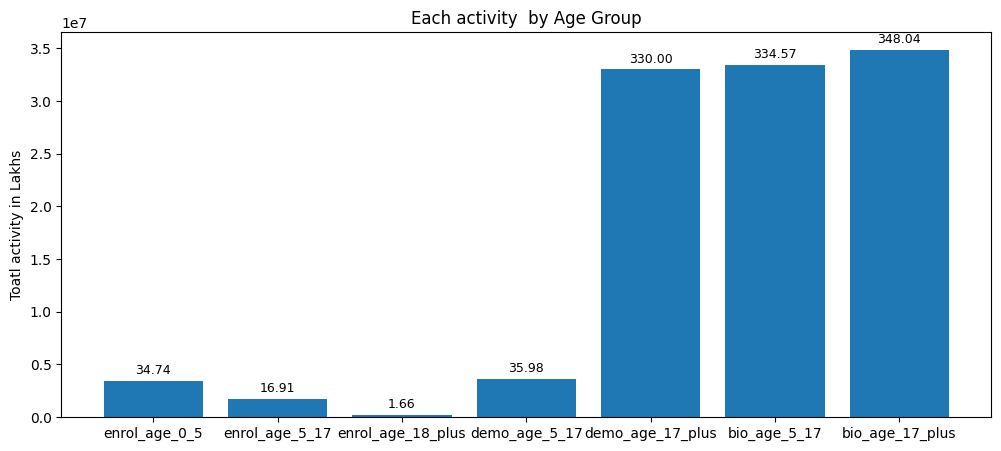

In [541]:
fig,ax=plt.subplots(figsize=(12,5))
bars = ax.bar(
    age_sum.index,
    age_sum.values
)
ax.bar_label(
    bars,
    labels=[f'{v/100000:.2f}' for v in age_sum.values],
    fontsize=9,
    padding=3
)
ax.set_ylabel('Toatl activity in Lakhs')
ax.set_title('Each activity  by Age Group')
plt.show()

“The data shows that while enrolment activity is concentrated in younger age groups, overall system usage is heavily driven by demographic and biometric updates, especially in the 17+ age category. Biometric activity is consistently high across age groups, indicating frequent verification and update requirements rather than new user onboarding.”

In [542]:
# Total activity per row
df['total']=df[cols].sum(axis=1)

In [543]:
# State-level aggregation
state_age_sum=df.groupby('state')[cols+['total']].sum().sort_values(by='total',ascending=False)

/tmp/ipython-input-88297484.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [544]:
state_age_sum

,enrol_age_0_5,enrol_age_5_17,enrol_age_18_plus,demo_age_5_17,demo_age_17_plus,bio_age_5_17,bio_age_17_plus,total
state,,,,,,,,
uttar pradesh,511727,473205,17699,603453,5857058,6076420,3290663,16830225
maharashtra,274274,81069,8103,204293,3620598,3437083,5583627,13209047
bihar,254911,327043,11799,285883,3352961,2160544,2618424,9011565
madhya pradesh,363244,115172,9476,289711,1814924,3148670,2671066,8412263
tamil nadu,178294,36214,1202,242100,1444494,2153303,2418849,6474456
rajasthan,224977,110131,5483,189180,1869716,2032783,1895214,6327484
west bengal,270419,90335,8495,177260,2667088,1023454,1458738,5695789
gujarat,188709,70270,16063,155182,1202933,1437932,1709956,4781045
andhra pradesh,96701,10059,1462,208769,1254669,2082783,1122735,4777178


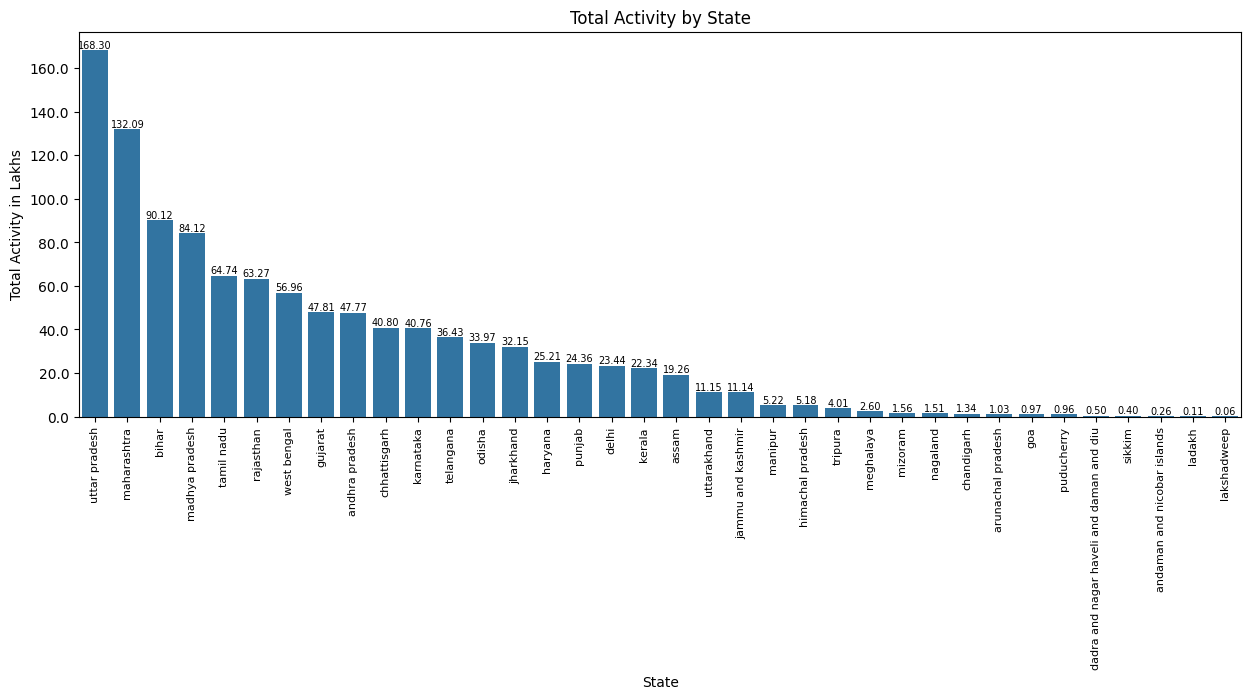

In [545]:
# Plot
plt.figure(figsize=(15,5))
sns.barplot( x=state_age_sum.index,y=state_age_sum['total'],order=state_age_sum.index)

ax=plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,pos: f'{x/1_00_000:.1f}'))

ax.set_ylabel('Total Activity in Lakhs')
ax.set_xlabel('State')
ax.set_title('Total Activity by State')
plt.xticks(rotation=90,fontsize=8)


# Bar labels

for bar in ax.patches:
  height=bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width()/2,height,f'{height/1_00_000:.2f}',
  ha='center',va='bottom',fontsize=7
  )

Uttar Pradesh has the highest total Aadhaar activity, followed by Maharashtra and Bihar.

High-population states dominate overall activity.

Southern states show steady, mid-to-high activity levels.

North-Eastern states and UTs contribute very little due to low population.

Aadhaar usage is highly concentrated in a few large states.

In [546]:
enrol_cols=['enrol_age_0_5','enrol_age_5_17','enrol_age_18_plus']

In [547]:
# Toatal enrolment by each state
df['enrol_total']=df[enrol_cols].sum(axis=1)

In [548]:
# state level total enrolment
state_enrol_sum=df.groupby('state')[enrol_cols+['enrol_total']].sum().sort_values(by='enrol_total',ascending=False)

/tmp/ipython-input-1148230652.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [549]:
state_enrol_sum

,enrol_age_0_5,enrol_age_5_17,enrol_age_18_plus,enrol_total
state,,,,
uttar pradesh,511727,473205,17699,1002631
bihar,254911,327043,11799,593753
madhya pradesh,363244,115172,9476,487892
west bengal,270419,90335,8495,369249
maharashtra,274274,81069,8103,363446
rajasthan,224977,110131,5483,340591
gujarat,188709,70270,16063,275042
assam,137983,64905,22614,225502
karnataka,176178,33402,10038,219618


In [550]:
# ----- Percentage calculation -----
for col in enrol_cols:
    state_enrol_sum[f'{col}_pct'] = (
        state_enrol_sum[col] / state_enrol_sum['enrol_total']
    ) * 100


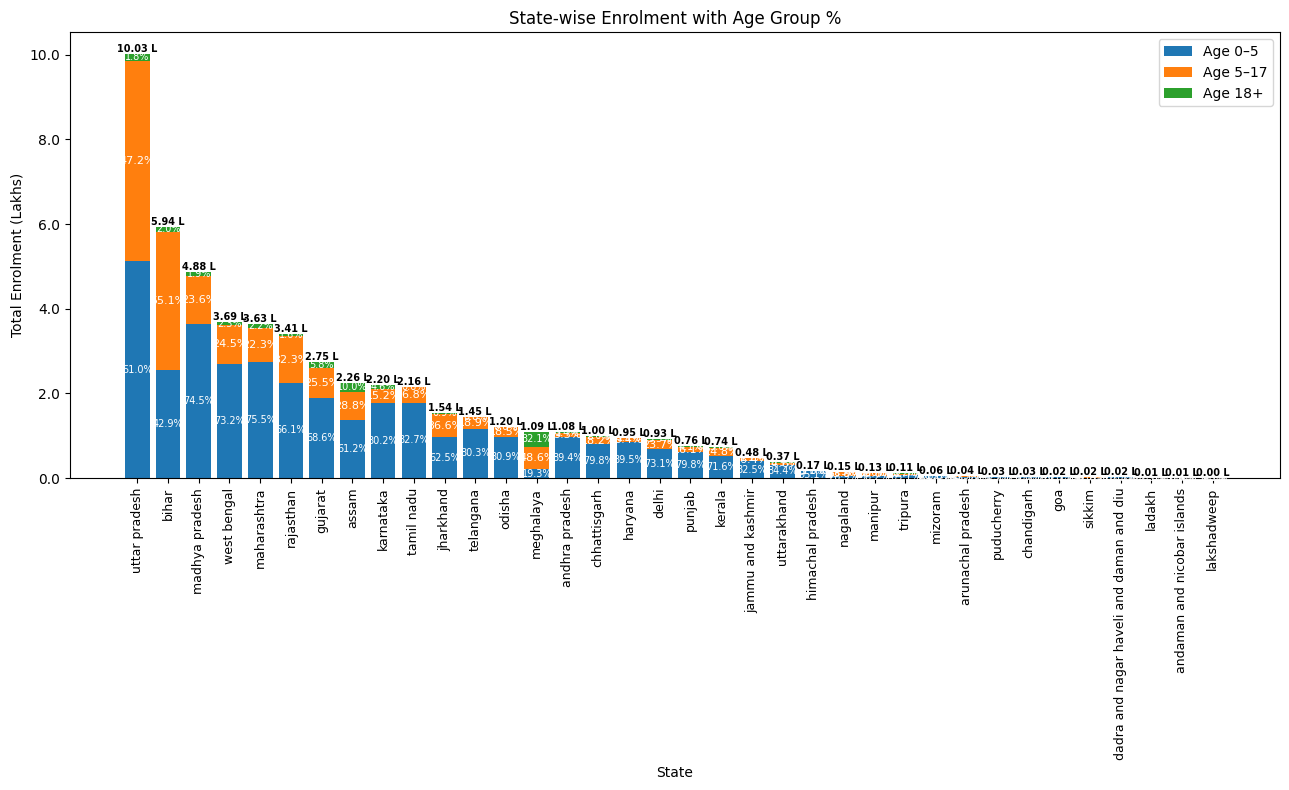

In [551]:
plt.figure(figsize=(13,8))

states = state_enrol_sum.index

age_0_5 = state_enrol_sum['enrol_age_0_5']
age_5_17 = state_enrol_sum['enrol_age_5_17']
age_18p = state_enrol_sum['enrol_age_18_plus']

plt.bar(states, age_0_5, label='Age 0–5')
plt.bar(states, age_5_17, bottom=age_0_5, label='Age 5–17')
plt.bar(states, age_18p, bottom=age_0_5 + age_5_17, label='Age 18+')

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1_00_000:.1f}'))

ax.set_ylabel('Total Enrolment (Lakhs)')
ax.set_xlabel('State')
ax.set_title('State-wise Enrolment with Age Group %')
plt.xticks(rotation=90, fontsize=9)
plt.legend()

# ---- Percentage labels inside each stack ----
for i, state in enumerate(states):

    # 0–5
    ax.text(
        i,
        age_0_5.iloc[i] / 2,
        f"{state_enrol_sum['enrol_age_0_5_pct'].iloc[i]:.1f}%",
        ha='center',
        va='center',
        fontsize=7,
        color='white'
    )

    # 5–17
    ax.text(
        i,
        age_0_5.iloc[i] + age_5_17.iloc[i] / 2,
        f"{state_enrol_sum['enrol_age_5_17_pct'].iloc[i]:.1f}%",
        ha='center',
        va='center',
        fontsize=8,
        color='white'
    )

    # 18+
    ax.text(
        i,
        age_0_5.iloc[i] + age_5_17.iloc[i] + age_18p.iloc[i] / 2,
        f"{state_enrol_sum['enrol_age_18_plus_pct'].iloc[i]:.1f}%",
        ha='center',
        va='center',
        fontsize=7,
        color='white'
    )

# ---- Total label on top ----
for i, total in enumerate(state_enrol_sum['enrol_total']):
    ax.text(
        i,
        total,
        f'{total/1_00_000:.2f} L',
        ha='center',
        va='bottom',
        fontsize=7,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


Uttar Pradesh records the highest total enrolment, followed by Bihar and Madhya Pradesh, due to their large population size. Across states, the 0–5 age group forms the largest share of enrolment, while the 5–17 age group represents a significant portion, indicating strong participation of school-going children. Assam and Meghalaya show relatively higher enrolment in the 5–17 age group, reflecting effective school-linked enrolment. Enrolment in the 18+ age group remains low across states, partly influenced in Assam by recent restrictions on first-time adult Aadhaar enrolment. Overall, enrolment in India remains predominantly child-centric, shaped by state-level administrative and policy measures.

In [552]:
# update intensity=(demo+bio)/total
update_cols = (df['demo_age_5_17'].sum() + df['demo_age_17_plus'].sum() + df['bio_age_5_17'].sum() + df['bio_age_17_plus'].sum())
update_intensity=update_cols/df['total'].sum()
update_intensity

np.float64(0.9516150421968278)

**Update intensity measures the proportion of demographic and biometric updates relative to total enrolment.**

In [553]:
enrol_total = (
    df['enrol_age_0_5'].sum()
    + df['enrol_age_5_17'].sum()
    + df['enrol_age_18_plus'].sum()
)
update_total = (
    df['demo_age_5_17'].sum()
    + df['demo_age_17_plus'].sum()
    + df['bio_age_5_17'].sum()
    + df['bio_age_17_plus'].sum()
)
# AMI = (demographic updates + biometric updates) / enrolments
AMINorm= update_total/enrol_total
AMINorm

np.float64(19.667580285343124)

**AMINorm represents the proportion of demographic and biometric updates relative to total enrolment.**

In [554]:
# BSI = biometric_17_plus / age_18_greater
BSI_norm = (
    df['bio_age_17_plus'].sum() /
    (
        df['bio_age_17_plus'].sum() +
        df['demo_age_17_plus'].sum() +
        df['enrol_age_18_plus'].sum()
    )
)
BSI_norm

np.float64(0.5120519241928488)

**BSI_norm represents the relative intensity of biometric updates among the adult population (17+), normalized against total adult-related enrolment and updates.**

In [555]:
# CII = (age_0_5 + age_5_17) / total
# Child Inclusion Index (CII)
CII = (
    (df['enrol_age_0_5'].sum() + df['enrol_age_5_17'].sum()) /
    df['total'].sum()
)
CII*100

np.float64(4.687621140019269)

**CII_percent represents the proportion of child enrolment (0–17 years) relative to total enrolment at the state level.**

In [556]:
# total activity by each age group
age_activity_df=pd.DataFrame({
    'Age_Group':['0_5','5_17','18_plus'],
    'Total_Activity':[
        df['enrol_age_0_5'].sum(),
        (df['enrol_age_5_17'].sum() + df['demo_age_5_17'].sum() + df['bio_age_5_17'].sum()),
        (df['enrol_age_18_plus'].sum() + df['demo_age_17_plus'].sum() + df['bio_age_17_plus'].sum())
    ]
 })

# Convert to Lakhs
age_activity_df['Total Activity (Lakhs)'] = age_activity_df['Total_Activity'] / 100_000

In [557]:
age_activity_df

,Age_Group,Total_Activity,Total Activity (Lakhs)
0,0_5,3474389,34.74389
1,5_17,38745292,387.45292
2,18_plus,67970474,679.70474


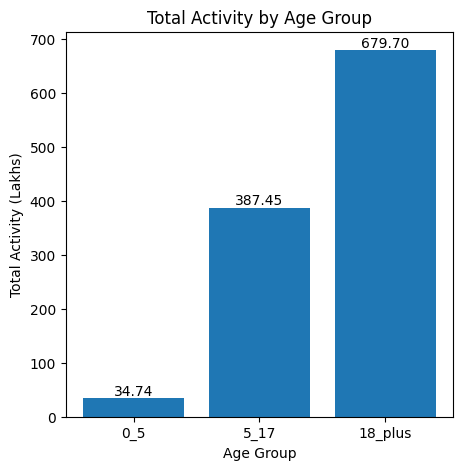

In [558]:
plt.figure(figsize=(5,5))

plt.bar(
    age_activity_df['Age_Group'],
    age_activity_df['Total Activity (Lakhs)']
)

for i, v in enumerate(age_activity_df['Total Activity (Lakhs)']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom')

plt.xlabel('Age Group')
plt.ylabel('Total Activity (Lakhs)')
plt.title('Total Activity by Age Group')
plt.show()

Most of the total activity comes from the 18+ age group.
The 0–5 age group shows very low activity compared to others.

### **State Wise Activity**

In [559]:
COUNT_COLS = ['enrol_age_0_5','enrol_age_5_17','enrol_age_18_plus','demo_age_5_17',
              'demo_age_17_plus','bio_age_5_17','bio_age_17_plus']

state_df = (df.groupby('state', as_index=True)[COUNT_COLS].sum())


/tmp/ipython-input-1670887304.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [560]:
state_df['total_lakhs'] = state_df.sum(axis=1)/100000

In [561]:
state_df['Enrolment']=(
        state_df['enrol_age_0_5']
        + state_df['enrol_age_5_17']
        + state_df['enrol_age_18_plus']
    )
state_df['Demographic_Update'] = (
    state_df['demo_age_5_17'] +
    state_df['demo_age_17_plus'])
state_df['Biometric_Update'] = (
    state_df['bio_age_5_17'] +
    state_df['bio_age_17_plus'])

In [562]:
enrolment_update_ratio_top=(state_df['Enrolment']/(state_df['Biometric_Update'] + state_df['Demographic_Update'])).sort_values(ascending=False).reset_index(name='ratio').head(10)

enrolment_update_ratio_bottom=(state_df['Enrolment']/(state_df['Biometric_Update'] + state_df['Demographic_Update'])).sort_values(ascending=True).reset_index(name='ratio').head(10)

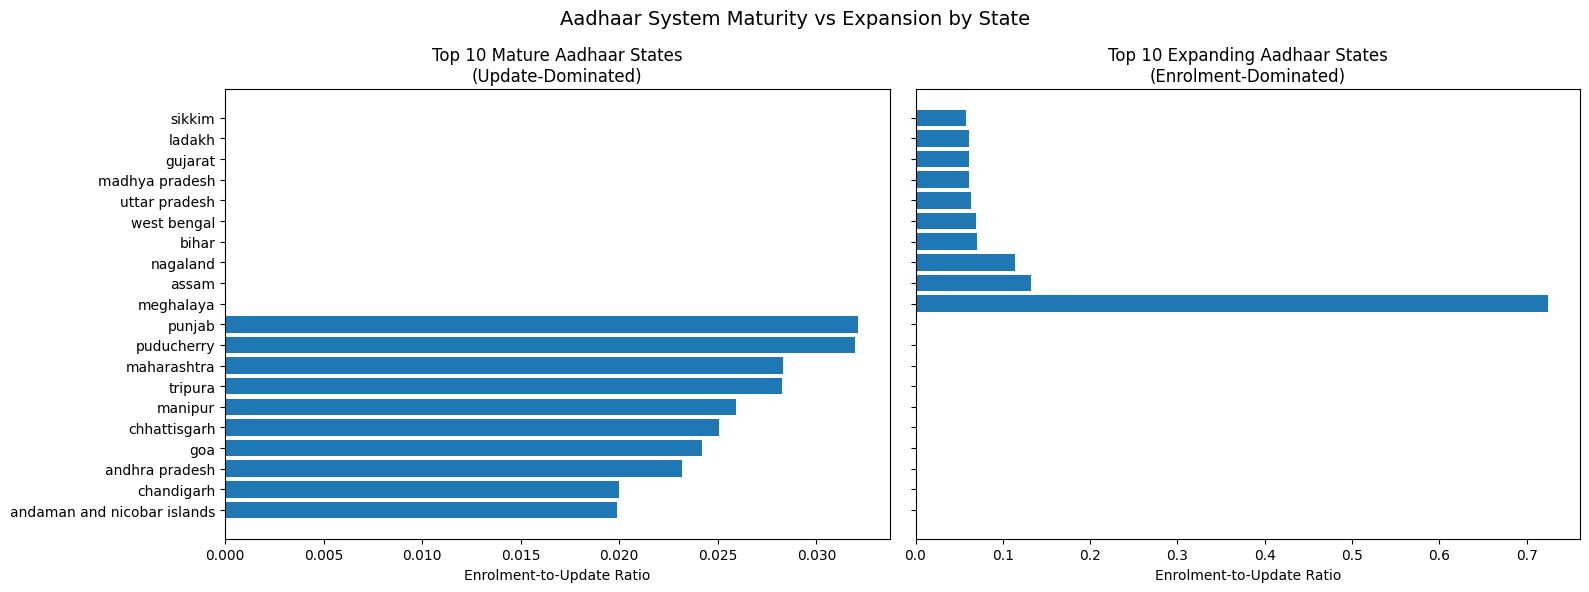

In [563]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Mature states (low ratio)
axes[0].barh(
    enrolment_update_ratio_bottom['state'],
    enrolment_update_ratio_bottom['ratio']
)
axes[0].set_title('Top 10 Mature Aadhaar States\n(Update-Dominated)')
axes[0].set_xlabel('Enrolment-to-Update Ratio')

# Expanding states (high ratio)
axes[1].barh(
    enrolment_update_ratio_top['state'],
    enrolment_update_ratio_top['ratio']
)
axes[1].set_title('Top 10 Expanding Aadhaar States\n(Enrolment-Dominated)')
axes[1].set_xlabel('Enrolment-to-Update Ratio')

plt.suptitle('Aadhaar System Maturity vs Expansion by State', fontsize=14)
plt.tight_layout()
plt.show()

The left figure shows states with a low enrolment-to-update ratio, indicating a mature Aadhaar system where demographic and biometric updates dominate due to high coverage and saturation.
The right figure highlights states with a high enrolment-to-update ratio, reflecting an expansion phase driven by first-time registrations. Assam and Meghalaya feature prominently in this group, where state-specific government directives related to Aadhaar enrolment led to a temporary surge in new enrolments, particularly among younger populations. Overall, the figures demonstrate how Aadhaar activity across states is shaped by both system maturity and policy interventions

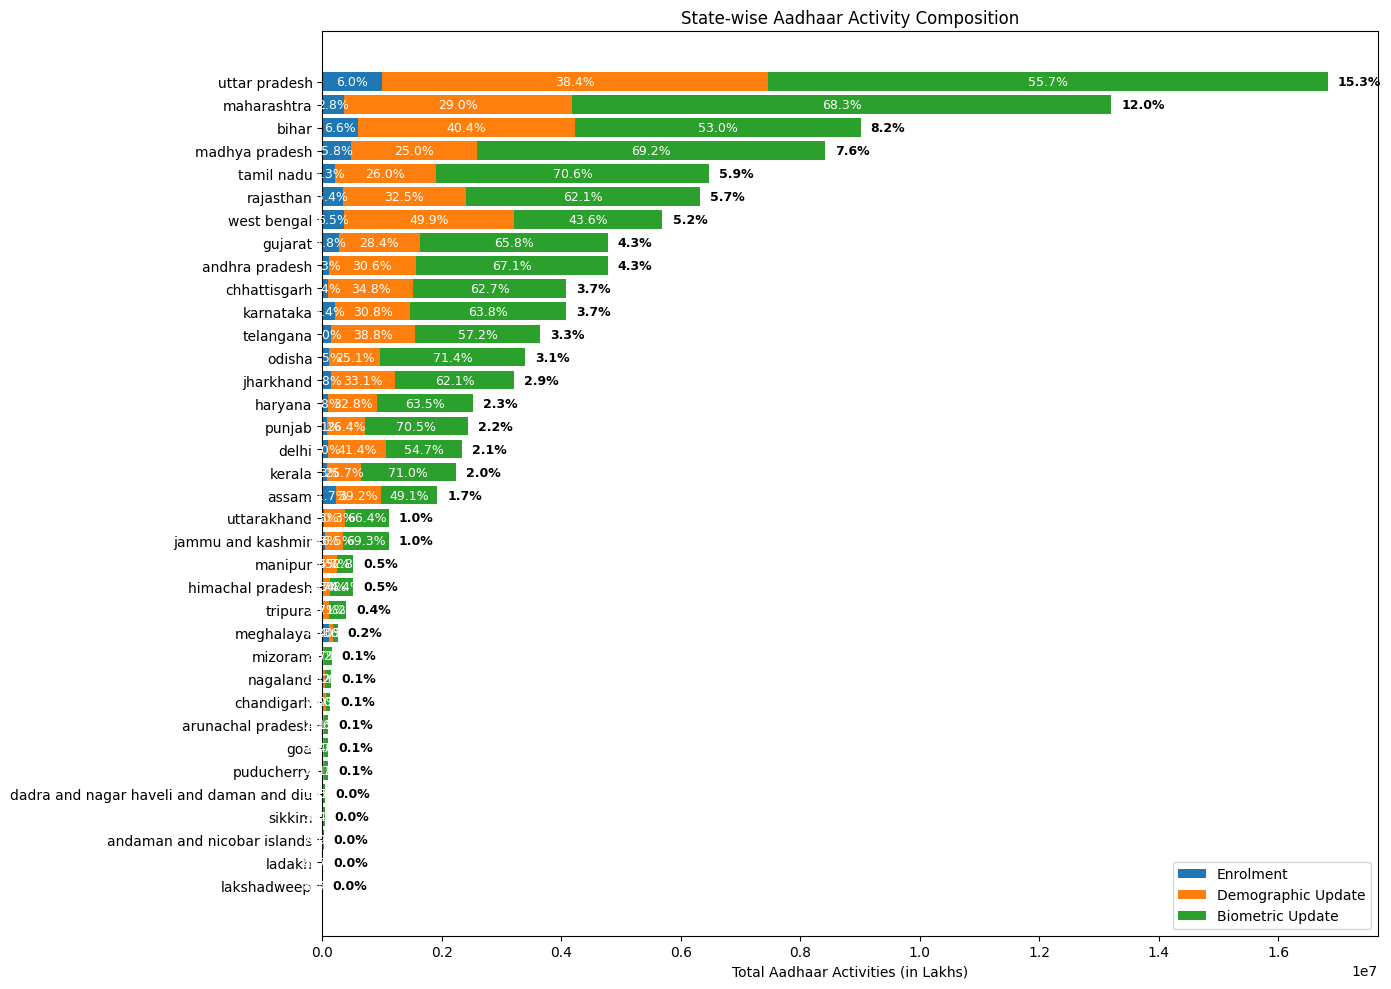

In [564]:
plot_df = state_df.copy().reset_index()
plot_df['total_lakhs'] = (
    plot_df['Enrolment'] +
    plot_df['Demographic_Update'] +
    plot_df['Biometric_Update']
)
plot_df['state_share_pct'] = (
    plot_df['total_lakhs'] / plot_df['total_lakhs'].sum() * 100
)
plot_df = plot_df.sort_values('total_lakhs')
fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(plot_df['state'], plot_df['Enrolment'], label='Enrolment')
ax.barh(
    plot_df['state'],
    plot_df['Demographic_Update'],
    left=plot_df['Enrolment'],
    label='Demographic Update'
)
ax.barh(
    plot_df['state'],
    plot_df['Biometric_Update'],
    left=plot_df['Enrolment'] + plot_df['Demographic_Update'],
    label='Biometric Update'
)
ax.set_xlabel('Total Aadhaar Activities (in Lakhs)')
ax.set_title('State-wise Aadhaar Activity Composition')
ax.legend()
for _, row in plot_df.iterrows():
    total = row['total_lakhs']
    if total == 0:
        continue
    enrol_pct = row['Enrolment'] / total * 100
    demo_pct  = row['Demographic_Update'] / total * 100
    bio_pct   = row['Biometric_Update'] / total * 100
    ax.text(
        row['Enrolment'] / 2,
        row['state'],
        f"{enrol_pct:.1f}%",
        va='center',
        ha='center',
        color='white',
        fontsize=9
    )
    ax.text(
        row['Enrolment'] + row['Demographic_Update'] / 2,
        row['state'],
        f"{demo_pct:.1f}%",
        va='center',
        ha='center',
        color='white',
        fontsize=9
    )
    ax.text(
        row['Enrolment'] + row['Demographic_Update'] + row['Biometric_Update'] / 2,
        row['state'],
        f"{bio_pct:.1f}%",
        va='center',
        ha='center',
        color='white',
        fontsize=9
    )
offset = plot_df['total_lakhs'].max() * 0.01
for _, row in plot_df.iterrows():
    ax.text(
        row['total_lakhs'] + offset,
        row['state'],
        f"{row['state_share_pct']:.1f}%",
        va='center',
        ha='left',
        fontsize=9,
        fontweight='bold'
    )
plt.tight_layout()
plt.show()


**The figure shows that Uttar Pradesh, Maharashtra, and Bihar account for the highest Aadhaar activity volumes, mainly due to their large populations. In most large states, biometric updates form the dominant share, indicating a relatively mature Aadhaar ecosystem with high existing coverage. Demographic updates also contribute significantly, especially in states like West Bengal and Bihar, reflecting frequent information corrections and updates. Assam and Meghalaya, despite lower overall volumes, exhibit comparatively higher enrolment shares, which can be linked to government directives and administrative measures that temporarily expanded Aadhaar enrolment coverage in these states. Overall, the composition highlights clear differences between mature states driven by updates and emerging or policy-driven states where enrolment activity remains prominent.**

In [565]:
import plotly.express as px

plot_df1 = state_df.copy().reset_index()
plot_df1['total_activity'] = (
    plot_df1['Enrolment'] +
    plot_df1['Demographic_Update'] +
    plot_df1['Biometric_Update']
)

# Update intensity
plot_df1['update_intensity'] = (
    (plot_df1['Demographic_Update'] + plot_df1['Biometric_Update']) /
    plot_df1['total_activity']
)
top_update_inst = (
    plot_df1
    .sort_values('update_intensity', ascending=False)
    .head(10)
)
fig = px.bar(
    top_update_inst,
    x='update_intensity',
    y='state',
    orientation='h',
    text=top_update_inst['update_intensity'].apply(lambda x: f'{x:.1%}'),
    color='update_intensity',
    color_continuous_scale='Blues',
    title='Top 10 States by Aadhaar Update Intensity'
)
fig.update_layout(
    xaxis_title='Update Intensity (Share of Total Aadhaar Activity)',
    yaxis_title='State',
    xaxis_tickformat='.0%',
    template='plotly_white',
    height=500,
    width=800

)

fig.update_traces(textposition='outside')

fig.show()

**The chart shows that states such as Andaman & Nicobar Islands, Chandigarh, Andhra Pradesh, and Goa have the highest Aadhaar update intensity, with more than 97% of total activity driven by updates. This indicates a highly mature Aadhaar ecosystem, where enrolment is largely saturated and activity mainly involves biometric and demographic updates. Smaller states and Union Territories dominate the list, reflecting stable populations and near-universal Aadhaar coverage. In contrast to enrolment-heavy states, these regions rely on Aadhaar primarily for maintenance and life-cycle updates. Overall, high update intensity serves as a strong indicator of system maturity and long-term administrative integration of Aadhaar.**

In [566]:
plot_df3 = state_df.copy().reset_index()
# Total updates
plot_df3['total_updates'] = (
    plot_df3['Demographic_Update'] + plot_df3['Biometric_Update']
)
# Enrolment-to-update ratio (safe division)
plot_df3['enrol_update_ratio'] = (
    plot_df3['Enrolment'] / plot_df3['total_updates'].replace(0, np.nan)
)

# Scatter plot
fig = px.scatter(
    plot_df3,
    x='enrol_update_ratio',
    y='total_lakhs',
    size='total_lakhs',
    color='total_lakhs',
    hover_name='state',
    color_continuous_scale='Viridis',
    labels={
        'enrol_update_ratio': 'Enrolment-to-Update Ratio',
        'total_lakhs': 'Total Aadhaar Activity (Lakhs)'
    },
    title='Aadhaar Ecosystem Maturity Matrix (State-wise)'
)

# Median reference lines
fig.add_vline(
    x=plot_df3['enrol_update_ratio'].median(),
    line_dash='dash',
    line_color='red',
    annotation_text='Median Enrol/Update Ratio',
    annotation_position='top'
)
fig.add_hline(
    y=plot_df3['total_lakhs'].median(),
    line_dash='dash',
    line_color='blue',
    annotation_text='Median Activity',
    annotation_position='right'
)
# Layout
fig.update_layout(
    height=650,
    width=500,
    template='plotly_white'
)

fig.show()


**The matrix clearly distinguishes enrolment-driven and update-driven states. States on the right with high enrolment-to-update ratios represent expanding Aadhaar ecosystems dominated by new enrolments. Assam and Meghalaya lie closer to this enrolment-heavy zone, reflecting increased enrolment activity influenced by policy-driven initiatives in the North-East. In contrast, states with lower ratios indicate mature systems where Aadhaar coverage is largely complete and updates dominate. Overall, the chart captures the progression from expansion to maturity in the Aadhaar lifecycle.**

In [567]:
mean_ratio = plot_df3['enrol_update_ratio'].mean(skipna=True)
std_ratio  = plot_df3['enrol_update_ratio'].std(skipna=True)

plot_df3['z_score'] = (
    (plot_df3['enrol_update_ratio'] - mean_ratio) / std_ratio
)

# Identify anomalies (|z| > 2)
anomalies = plot_df3.loc[plot_df3['z_score'].abs() > 2]
anomalies[['state', 'enrol_update_ratio', 'total_lakhs', 'z_score']]


,state,enrol_update_ratio,total_lakhs,z_score
22,meghalaya,0.724818,2.59611,5.708476


**States with absolute z-scores greater than 2 are identified as anomalies, indicating unusually high or low enrolment-to-update ratios compared to the national pattern. Such deviations may reflect state-specific administrative actions, targeted enrolment drives, or policy interventions influencing Aadhaar activity levels.**

In [568]:
plot_df = state_df.copy().reset_index(names='state')
# Biometric Saturation Index (safe division)
plot_df['BSI_norm'] = (
    plot_df['bio_age_17_plus'] /
    (
        plot_df['bio_age_17_plus'] +
        plot_df['demo_age_17_plus'] +
        plot_df['enrol_age_18_plus']
    )
)
plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
top_bsi = plot_df.sort_values('BSI_norm', ascending=False)
fig = px.bar(
    top_bsi,
    x='BSI_norm',
    y='state',
    orientation='h',
    text=top_bsi['BSI_norm'].round(2),
    color='BSI_norm',
    color_continuous_scale='Reds',
    title='Top 10 States by Biometric Saturation Index (BSI norm)'
)
fig.update_layout(
    xaxis_title='Biometric Saturation Index (BSI norm)',
    yaxis_title='State',
    xaxis_tickformat='.1f',
    template='plotly_white',
    height=700,
    width=800
)
fig.update_traces(textposition='outside')
fig.show()
'''< 0.4	Expanding identity base
0.4-0.7	Stabilizing
> 0.7	Highly saturated'''

'< 0.4\tExpanding identity base\n0.4-0.7\tStabilizing\n> 0.7\tHighly saturated'

**The BSI chart highlights differences in biometric maturity across states. Smaller and North-Eastern states like Assam and Meghalaya show relatively lower BSI values, indicating scope for further biometric updates. In contrast, larger and more mature states have higher BSI, reflecting near-saturation of biometric coverage. Overall, the pattern distinguishes states still expanding their biometric base from those with largely completed Aadhaar biometric updates.**

In [569]:
# Total Aadhaar activity (absolute numbers)
plot_df['total_activity'] = (
    plot_df['Enrolment'] +
    plot_df['Demographic_Update'] +
    plot_df['Biometric_Update']
)

# Child Inclusion Index (CII)
plot_df['CII'] = (
    (plot_df['enrol_age_0_5'] + plot_df['enrol_age_5_17']) /
    plot_df['total_activity'].replace(0, np.nan)
)
top_cii = plot_df.sort_values('CII', ascending=False).head(10)

fig = px.bar(
    top_cii,
    x='CII',
    y='state',
    orientation='h',
    text=top_cii['CII'].apply(lambda x: f'{x:.1%}'),
    color='CII',
    color_continuous_scale='Greens',
    title='Top 10 States by Child Inclusion Index (CII)'
)

fig.update_layout(
    xaxis_title='Child Inclusion Index (Share of Total Activity)',
    yaxis_title='State',
    xaxis_tickformat='.0%',
    template='plotly_white',
    height=500,
    width=700
)

fig.update_traces(textposition='outside')
fig.show()
'''CII Value	Meaning
< 5%	Adult-dominated system
5-15%	Balanced inclusion
> 15%	Strong child-centric enrolment'''

'CII Value\tMeaning\n< 5%\tAdult-dominated system\n5-15%\tBalanced inclusion\n> 15%\tStrong child-centric enrolment'

**The Child Inclusion Index reveals that Aadhaar activity in several North-Eastern states is strongly child-centric, with Meghalaya showing exceptionally high child inclusion, followed by Assam and Nagaland. This indicates focused enrolment drives for children and early-age Aadhaar coverage in these regions. In contrast, larger states fall in a moderate CII range, reflecting balanced systems where new child enrolments and adult updates coexist. Overall, the index shows that Aadhaar expansion is still underway in some states, while others have transitioned toward maturity with reduced dependence on child enrolments.**

In [570]:
'''Create a Composite Inclusion-Maturity Score:
AIMS=0.4(1-Update Intensity)+0.3(1-BSInorm)+0.3(CII)
AIMS=0.4(1-Update Intensity)+0.3(1-BSI
norm
)+0.3(CII)
➡ One number per state → rankable, comparable'''
# Update intensity (0–1)
plot_df['update_intensity'] = (
    (plot_df['Demographic_Update'] + plot_df['Biometric_Update']) /
    plot_df['total_activity'].replace(0, np.nan)
)
plot_df['AIMS'] = (
    0.4 * (1 - plot_df['update_intensity']) +
    0.3 * (1 - plot_df['BSI_norm']) +
    0.3 * plot_df['CII']
)
# Rank states (higher = better inclusion-maturity balance)
plot_df['AIMS_rank'] = plot_df['AIMS'].rank(ascending=False)
top_aims = plot_df.sort_values('AIMS', ascending=False).head(10)
fig = px.bar(
    top_aims,
    x='AIMS',
    y='state',
    orientation='h',
    text=top_aims['AIMS'].round(3),
    color='AIMS',
    color_continuous_scale='Teal',
    title='Top 10 States by Composite Inclusion-Maturity Score (AIMS)'
)
fig.update_layout(
    xaxis_title='AIMS (Higher = Better Balance)',
    yaxis_title='State',
    template='plotly_white',
    height=500,
    width=700
)
fig.update_traces(textposition='outside')
fig.show()
'''AIMS Range	Meaning
> 0.6	Strong inclusion + sustainable maturity
0.45 - 0.6	Balanced / stable
< 0.45	Aging or saturated ecosystem'''

'AIMS Range\tMeaning\n> 0.6\tStrong inclusion + sustainable maturity\n0.45 - 0.6\tBalanced / stable\n< 0.45\tAging or saturated ecosystem'

**The Composite Inclusion-Maturity Score (AIMS) shows that Meghalaya and Assam rank highest, indicating a strong balance between new enrolments, child inclusion, and system maturity. These states combine active inclusion with relatively lower saturation, reflecting expansion-phase Aadhaar ecosystems. States like West Bengal and Uttar Pradesh fall in the balanced range, where enrolment and updates coexist steadily. In contrast, states with lower AIMS values represent more mature or saturated systems dominated by updates. Overall, AIMS effectively identifies states that are progressing toward sustainable and well-balanced Aadhaar development.**

In [571]:
fig = px.scatter(
    plot_df,
    x='AIMS',
    y='total_lakhs',
    size='total_lakhs',
    color='AIMS',
    hover_name='state',
    color_continuous_scale='Viridis',
    labels={
        'AIMS': 'Composite Inclusion-Maturity Score',
        'total_lakhs': 'Total Aadhaar Activity (Lakhs)'
    },
    title='Inclusion-Maturity Balance vs Aadhaar Scale'
)
fig.add_vline(
    x=plot_df['AIMS'].median(),
    line_dash='dash',
    annotation_text='Median AIMS'
)

fig.update_layout(
    template='plotly_white',
    height=650,
    width=700
)
fig.show()

**The scatter plot shows how Aadhaar system balance (AIMS) varies with the scale of Aadhaar activity across states. States with higher AIMS values, positioned to the right of the median line, reflect a healthier balance between inclusion and maturity regardless of system size. Large states tend to cluster at moderate AIMS levels, indicating stable but more update-driven ecosystems. Smaller states and North-Eastern regions display wider variation, with some achieving high AIMS due to strong enrolment and child inclusion. Overall, the chart highlights that system quality (balance) is not solely dependent on size, and smaller states can outperform larger ones in inclusion–maturity balance.**

In [572]:
'''lassify states into policy regimes, not just values.
Quadrant	Interpretation
High update, low CII	Aging population risk
Low update, high CII	Expanding child base
High-High	Balanced maturity
Low-Low	Lagging states'''

# Work on a copy
# Thresholds for quadrant split
update_thresh = plot_df['update_intensity'].median()
cii_thresh = plot_df['CII'].median()
def classify_regime(row):
    if row['update_intensity'] >= update_thresh and row['CII'] < cii_thresh:
        return 'Aging Population Risk'
    elif row['update_intensity'] < update_thresh and row['CII'] >= cii_thresh:
        return 'Expanding Child Base'
    elif row['update_intensity'] >= update_thresh and row['CII'] >= cii_thresh:
        return 'Balanced Maturity'
    else:
        return 'Lagging States'
plot_df['policy_regime'] = plot_df.apply(classify_regime, axis=1)
fig = px.scatter(
    plot_df,
    x='update_intensity',
    y='CII',
    color='policy_regime',
    size='total_lakhs',
    hover_name='state',
    color_discrete_map={
        'Aging Population Risk': '#d62728',
        'Expanding Child Base': '#2ca02c',
        'Balanced Maturity': '#1f77b4',
        'Lagging States': '#7f7f7f'
    },
    labels={
        'update_intensity': 'Update Intensity (Higher = Mature)',
        'CII': 'Child Inclusion Index'
    },
    title='State-wise Aadhaar Policy Regimes'
)
# Add quadrant lines
fig.add_vline(
    x=update_thresh,
    line_dash='dash',
    line_color='black'
)

fig.add_hline(
    y=cii_thresh,
    line_dash='dash',
    line_color='black'
)

# Quadrant annotations
fig.add_annotation(x=0.95, y=0.05, text='Aging Population Risk',
                   showarrow=False, xref='paper', yref='paper')
fig.add_annotation(x=0.05, y=0.95, text='Expanding Child Base',
                   showarrow=False, xref='paper', yref='paper')
fig.add_annotation(x=0.95, y=0.95, text='Balanced Maturity',
                   showarrow=False, xref='paper', yref='paper')
fig.add_annotation(x=0.05, y=0.05, text='Lagging States',
                   showarrow=False, xref='paper', yref='paper')

fig.update_layout(
    template='plotly_white',
    height=650,
    legend_title_text='Policy Regime'
)
fig.show()
'''Quadrant	What it Means	Policy Action
Aging Population Risk	High updates, low child enrolment	Focus on newborn & school enrolment
Expanding Child Base	Low updates, high child enrolment	Scale infra & capacity
Balanced Maturity	Healthy mix	Maintain & optimize
Lagging States	Low on both	Outreach & accessibility'''


'Quadrant\tWhat it Means\tPolicy Action\nAging Population Risk\tHigh updates, low child enrolment\tFocus on newborn & school enrolment\nExpanding Child Base\tLow updates, high child enrolment\tScale infra & capacity\nBalanced Maturity\tHealthy mix\tMaintain & optimize\nLagging States\tLow on both\tOutreach & accessibility'

**States fall into distinct Aadhaar policy patterns—some are update-heavy with low child enrolment, others have strong child inclusion but lower maturity, a few show balanced performance, while some lag on both fronts. This highlights clear inter-state differences and the need for targeted, state-specific policy interventions rather than a uniform strategy.**

In [573]:
plot_df = plot_df.copy()
# Compute IQR for CII
Q1 = plot_df['CII'].quantile(0.25)
Q3 = plot_df['CII'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Identify outliers
plot_df['CII_outlier'] = (
    (plot_df['CII'] < lower_bound) |
    (plot_df['CII'] > upper_bound)
)
outliers = plot_df[plot_df['CII_outlier']]
outliers[['state', 'CII', 'total_lakhs']]
fig = px.scatter(
    plot_df,
    x='total_lakhs',
    y='CII',
    color='CII_outlier',
    hover_name='state',
    size='total_lakhs',
    color_discrete_map={True: 'red', False: 'gray'},
    labels={
        'total_lakhs': 'Total Aadhaar Activity (Lakhs)',
        'CII': 'Child Inclusion Index'
    },
    title='CII Outliers by Aadhaar Scale'
)
fig.add_hline(y=lower_bound,  line_dash='dash',
    line_color='blue',
    annotation_text='Lower-Bound',
    annotation_position='right',
              )
fig.add_hline(y=upper_bound, line_dash='dash',
              line_color='red',
              annotation_text='Upper-Bound',
              annotation_position='right')

fig.update_layout(
    template='plotly_white',
    height=650
)

fig.show()
'''Outlier Type	Meaning
High CII	Exceptional child-centric enrolment
Low CII	Possible under-coverage or access gaps
“Using IQR-based outlier detection, we identify states with unusually high or low child inclusion, flagging potential data quality or policy attention areas.”
'''

'Outlier Type\tMeaning\nHigh CII\tExceptional child-centric enrolment\nLow CII\tPossible under-coverage or access gaps\n“Using IQR-based outlier detection, we identify states with unusually high or low child inclusion, flagging potential data quality or policy attention areas.”\n'

**Most states cluster within a narrow Child Inclusion Index (CII) range, indicating broadly similar child enrolment patterns. A few states emerge as high-CII outliers, reflecting exceptionally strong child-focused enrolment, while low-CII outliers signal potential access gaps or under-coverage. These outliers merit closer policy and data-quality review rather than being treated as normal variation.**

In [574]:
corr_df = plot_df[['CII', 'BSI_norm', 'update_intensity', 'total_lakhs']].copy()
# Correlation matrix
corr_matrix = corr_df.corr()
fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu',
    zmin=-1,
    zmax=1,
    title='Correlation Matrix: Aadhaar Structural Metrics'
)

fig.update_layout(
    template='plotly_white',
    height=500
)

fig.show()
'''Red → strong positive relationship

Blue → strong negative relationship

Near 0 → weak or no structural link'''

'Red → strong positive relationship\n\nBlue → strong negative relationship\n\nNear 0 → weak or no structural link'

**The matrix shows a very strong negative correlation between CII and update intensity, indicating that states with higher child inclusion typically have lower update activity, and vice versa. BSI_norm has only moderate links with update intensity and weak links with CII. Total Aadhaar scale (total_lakhs) is almost uncorrelated with the other metrics, suggesting that size does not drive inclusion or maturity patterns—these are structural, not scale-driven.**

In [575]:
fig = px.scatter(
    plot_df,
    x='total_lakhs',
    y='update_intensity',
    trendline='ols',
    hover_name='state',
    labels={
        'total_lakhs': 'Total Aadhaar Activity (Lakhs)',
        'update_intensity': 'Update Intensity'
    },
    title='Update Intensity vs Aadhaar Scale'
)
fig.update_layout(
    template='plotly_white',
    height=600
)
fig.show()

**Update intensity remains consistently high across all Aadhaar scales, with only a very weak positive trend. This shows that update activity is largely scale-independent—large states are not inherently more “mature” than smaller ones. Maturity appears driven by process efficiency and policy, not by the volume of Aadhaar activity.**

In [576]:
fig = px.scatter(
    plot_df,
    x='BSI_norm',
    y='CII',
    trendline='ols',
    hover_name='state',
    labels={
        'BSI_norm': 'Biometric Saturation Index (Normalized)',
        'CII': 'Child Inclusion Index'
    },
    title='Child Inclusion vs Biometric Saturation'
)

fig.update_layout(
    template='plotly_white',
    height=600
)

fig.show()

There is a clear negative relationship between biometric saturation and child inclusion. States with higher biometric saturation tend to have lower CII, indicating mature, adult-heavy Aadhaar ecosystems, while states with lower saturation show higher child enrolment, reflecting ongoing demographic expansion rather than system maturity.